In [2]:
# autoreload reloads modules automatically before entering the execution of code typed at the IPython prompt.
%load_ext autoreload
%autoreload 2

In [3]:
import qsharp_alice_bob_resource_estimator as qre
from helpers import print_summary, format_energy, hardware_params, estimate_total_energy

import numpy as np
import matplotlib.pyplot as plt
import scienceplots

# Use SciencePlots with additional clean style
plt.style.use(['science', 'no-latex', 'bright'])

# Algorithmic resource estimation for ECC

In [18]:
print(qre.elliptic_curve_estimate_struct.__doc__)

Structured variant of the ECC example that returns typed estimate objects.

# Arguments
- `bit_size` — ECC modulus bit size.
- `window_size` — Window size used by the example algorithm.
- `frontier` — If `true`, also return a list representing the frontier.

# Returns
A tuple:
1. `EstimatesPy` — single best estimate,
2. `Vec<EstimatesPy>` — optional frontier (empty if `frontier == false`).

# Errors
Propagates example execution or estimation errors as Python `RuntimeError`s.


In [5]:
bit_size = 256
window_size = 18
print("\n=== ECC example ===")
ecc_summary, _ = qre.elliptic_curve_estimate_struct(bit_size, window_size, frontier=False)
print_summary(ecc_summary)


=== ECC example ===
Parameters obtained from the Rust resource estimator
─────────────────────────────
# physical qubits:    115,203
runtime:             7.57 hrs
total error:         0.23104
─────────────────────────────
code distance:       13 (|α|² = 19.00)
#factories:          61
factories distance:  9 (|α|² = 12.83)
factory fraction:    4.50%
─────────────────────────────


# Energy estimation

# Example usage
## Elliptic curve cryptography

In [6]:
# Build Hardware
H = hardware_params()

In [7]:
bit_size = 256
window_size = 18
n_logical = 9 * bit_size + window_size + 4

summary_ecc, _ = qre.elliptic_curve_estimate_struct(bit_size, window_size, frontier=False)
print("\n=== ECC example ===")
result_ecc = estimate_total_energy(summary_ecc,H,n_logical, macro = True)



=== ECC example ===
Parameters obtained from the Rust resource estimator
─────────────────────────────
# physical qubits:    115,203
runtime:             7.57 hrs
total error:         0.23104
─────────────────────────────
code distance:       13 (|α|² = 19.00)
#factories:          61
factories distance:  9 (|α|² = 12.83)
factory fraction:    4.50%
─────────────────────────────
Number of logical qubits: 2326 
Energy consumption estimation
T_cycle:       3.024900e-06 s
Number of rounds:      9013651716
E_data_patch:  12 kJ
E_factory(one):8 kJ
E_factories:   481 kJ
E_total:       28MJ


## From Resource Estimation

In [19]:
print(qre.estimate_resources_struct.__doc__)

Estimate resources from explicit logical counts and return typed results,
optionally including a frontier of trade-offs.

# Arguments
- `qubits` — Logical (algorithm) qubit count.
- `cx` — Logical CX-equivalent two-qubit gate count.
- `ccx` — Logical CCX (Toffoli) gate count.
- `frontier` — If `true`, compute and return the frontier as structured objects.
- `error_total` — Overall error target; mutually exclusive with `error_budget`.
- `error_budget` — Tuple `(target, meas, routing)` for an explicit split.

# Returns
A tuple:
1. `EstimatesPy` — single best estimate,
2. `Vec<EstimatesPy>` — frontier (empty if `frontier == false`).

# Errors
Propagates errors from the physical resource estimator.


In [17]:
bit_size = 256
window_size = 18

import math

qubit_count = 9 * bit_size + window_size + 4

# Asymptotic gate counts, arXiv:2302.06639 (p. 21, app C.10)
cx_count = math.ceil(448 * bit_size**3 / window_size)
ccx_count = math.ceil(348 * bit_size**3 / window_size)


single, _ = qre.estimate_resources_struct(qubit_count,cx_count,ccx_count, frontier=False,error_total=None,error_budget=(0.333 * 0.5, 0.333 * 0.5, 0.0))
print_summary(single)


Parameters obtained from the Rust resource estimator
─────────────────────────────
# physical qubits:    115,203
runtime:             7.57 hrs
total error:         0.23104
─────────────────────────────
code distance:       13 (|α|² = 19.00)
#factories:          61
factories distance:  9 (|α|² = 12.83)
factory fraction:    4.50%
─────────────────────────────


# From Q# File

In [20]:
print(qre.estimate_file_struct.__doc__)

Estimate resources from a Q# file and return both the best estimate and, optionally,
a frontier of Pareto-optimal trade-offs, together with the parsed logical counts.

# Arguments
- `filename` — Path to a Q# source file to be parsed and interpreted for counts.
- `frontier` — If `true`, also compute a frontier of estimates (e.g., different distances/α).
- `error_total` — Overall error target `p_total`; mutually exclusive with `error_budget`.
- `error_budget` — Tuple `(target, meas, routing)` if an explicit split is desired.

# Returns
A 3-tuple:
1. `EstimatesPy` — the single best estimate,
2. `Vec<EstimatesPy>` — optionally, the frontier (empty if `frontier == false`),
3. `LogicalCountsPy` — Python snapshot of the logical counts extracted from `filename`.

# Errors
- I/O or parsing failures when loading the Q# file,
- Failures during resource estimation.

# Notes
Counts are placed behind `Rc` to share between the estimator and the Python view
without copying the full structure.


In [22]:
filename = "qsharp/Adder.qs"
single, frontier, counts = qre.estimate_file_struct(
    filename, 
    frontier=True, 
    error_total=None, 
    error_budget=(0.0005, 0.0005, 0.0)
)
print("\n=== Q# example ===")
result_qsharp = estimate_total_energy(single, H, counts.qubit_count, macro = True)


=== Q# example ===
Parameters obtained from the Rust resource estimator
─────────────────────────────
# physical qubits:    13,419
runtime:             0.00 hrs
total error:         0.00019
─────────────────────────────
code distance:       9 (|α|² = 14.00)
#factories:          2
factories distance:  5 (|α|² = 8.18)
factory fraction:    0.67%
─────────────────────────────
Number of logical qubits: 384 
Energy consumption estimation
T_cycle:       5.000000e-07 s
Number of rounds:      26595
E_data_patch:  0 J
E_factory(one):0 J
E_factories:   0 J
E_total:       12J


# Sweep for different ECC problem sizes

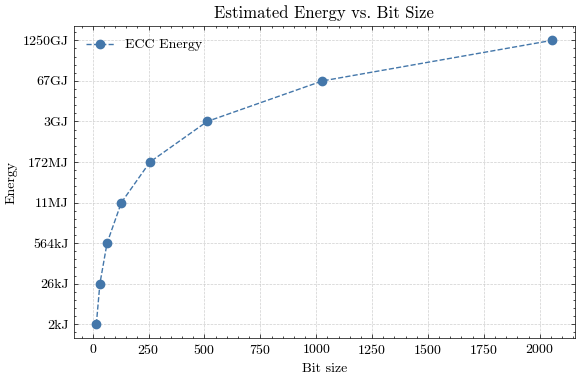

In [23]:
# Define bit sizes
bit_sizes = np.array([16, 32, 64, 128, 256, 512, 1028, 2056])
window_size = 18 # Fixed but might not be optimal
energies = []

# Compute energies
for bit_size in bit_sizes:
    n_logical = 9 * bit_size + window_size + 4
    result, _ = qre.elliptic_curve_estimate_struct(bit_size, window_size, frontier=False)
    etot = estimate_total_energy(result, H, n_logical, macro=True, display=False)["E_total"]
    energies.append(etot)

energies = np.array(energies)

# Plot
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(bit_sizes, energies, marker='o', linestyle='--', color='C0', label='ECC Energy')
ax.set_xlabel("Bit size")
ax.set_ylabel("Energy")
ax.set_title("Estimated Energy vs. Bit Size")
ax.grid(True, which='major', linestyle='--', alpha=0.6)
ax.legend()

# Optionally use log scale if energies vary a lot
# ax.set_yscale('log')
# ax.set_xscale('log')

plt.tight_layout()
plt.show()
